# HOMEWORK 1

After the installation of Anaconda, jupyter notebook and the required virtual environment, you will have to test that everything has been set up correctly. For that purpose, you will have to execute the following code and run it without errors.

The code loads an image and creates a picture collage consisting of 4 pictures. Each of the four pictures is a version of the original image with the colour channels swapped.

You will have to also finish some part of the code :-)

In [ ]:
# !pip install requests

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import requests
plt.rcParams['figure.figsize'] = [15, 10]

In [47]:
def load_image(url: str, save_fp: None | str = None):
    try:
        response = requests.get(url, stream=True)

        if response.status_code == 200:
            image = np.asarray(bytearray(response.raw.read()), dtype="uint8")
            image = cv2.imdecode(image, cv2.IMREAD_COLOR)
            if save_fp:
                cv2.imwrite(save_fp, image)
            return image
    except: 
        return cv2.imread("data/kodim21.png")
    
    

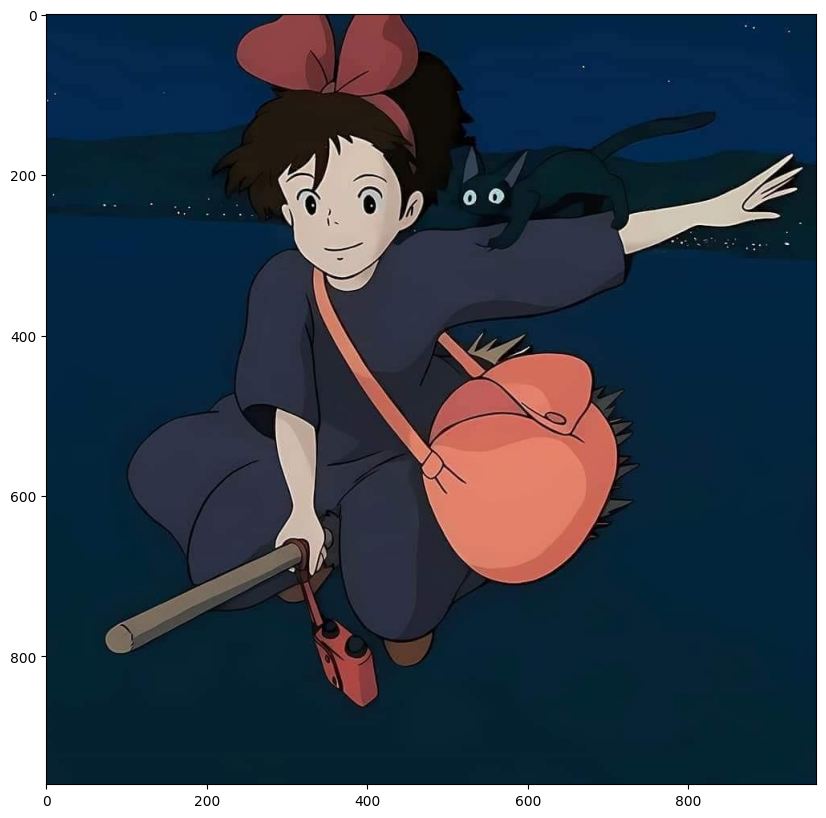

In [50]:
# Load an image (you can freely chose any image you like)
url = "https://i.pinimg.com/1200x/92/70/84/92708453361171fd585970c9afeb7e2c.jpg"
img = load_image(url, save_fp="data/kiki_the_witch.jpg")
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's make a collage.

(np.float64(-0.5), np.float64(1919.5), np.float64(1919.5), np.float64(-0.5))

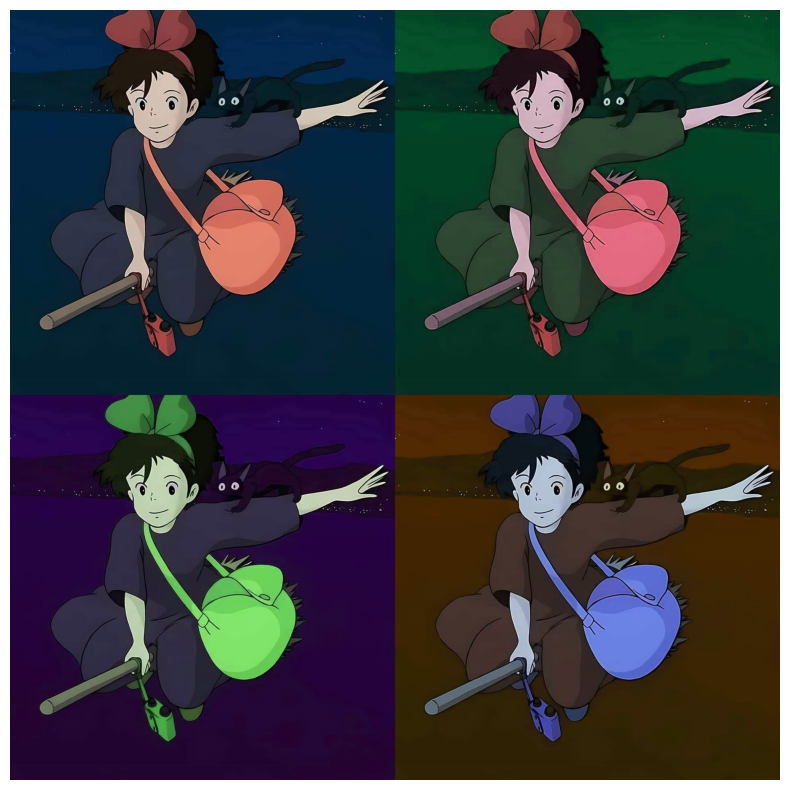

In [62]:
# Split the image into the three colour channels
red, green, blue = cv2.split(img)

# Compose the image in the RGB colour space
img1 = cv2.merge([red, green, blue])

# Compose the image in the RBG colour space
img2 = cv2.merge([red, blue, green])

# Compose the image in the GRB colour space
img3 = cv2.merge([green, red, blue])

# Compose the image in the BGR colour space
img4 = cv2.merge([blue, green, red])

# Create the collage
out1 = np.hstack([img1, img2])
out2 = np.hstack([img3, img4])
out = np.vstack([out1, out2])

# Plot the collage
plt.imshow(out)
plt.axis(False)